In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pythermalcomfort.models import pmv_ppd_iso
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

cities_label = {"London":"london", 
                "New York":"newyork", 
                "Beijing":"beijing",
                "Hong Kong":"hongkong",
                "Singapore":"singapore"}

colors = ["#3964DF", "#E0C645","#E02927",  "#65D8DF", "#AE02DE"]

def get_dynamic_parameters(month, hour):
    # --- 1. 判断是否是睡觉时间 (例如 23:00 - 07:00) ---
    is_sleeping = (hour >= 23) or (hour < 7)

    # --- 2. 设定 Met (代谢率) ---
    if is_sleeping:
        current_met = 0.7  # 睡觉模式：产热极低
    else:
        current_met = 1.2  # 日间模式：正常静坐

    # --- 3. 设定 Clo (服装/被褥) ---
    if is_sleeping:
        # 【关键修正】睡觉必须盖被子！
        # 冬天被子厚一点 (2.5), 夏天薄被子 (1.5)
        if month in [12, 1, 2]:
            current_clo = 2.5  # 厚棉被
        elif month in [6, 7, 8]:
            current_clo = 1.5  # 毯子/薄被
        else:
            current_clo = 2.0  # 普通被子
    else:
        # 白天穿衣服 (之前的逻辑)
        if month in [11, 12, 1, 2, 3, 4]:
            current_clo = 1.0  # 冬装
        elif month in [6, 7, 8]:
            current_clo = 0.5  # 夏装
        else:
            current_clo = 0.75 # 春秋装
    #current_clo, current_met = 1.0, 1.2  # 临时固定值，后续替换为动态计算
    return current_clo, current_met


price_ele =  pd.read_csv('london_avgprice.csv')
price_ele

,month,day,hour,ele_price
0,1,1,0.0,10.4195
1,1,1,0.5,13.1355
2,1,1,1.0,14.0525
3,1,1,1.5,8.5540
4,1,1,2.0,9.7160
...,...,...,...,...
17563,12,31,21.5,16.4570
17564,12,31,22.0,16.0860
17565,12,31,22.5,11.5885
17566,12,31,23.0,9.9575


In [2]:
def cost(P_ac, P_heat, tsa, ele_price):
    COP_cooling = -0.14 * (tsa - 273.15) + 7.31
    COP_heating = 0.07 * (tsa - 273.15) + 3.20
    P_ac = P_ac/COP_cooling*0.5
    P_heat = P_heat/COP_heating*0.5
    r = P_ac + P_heat
    r['time'] = r['time'].dt.round('min')
    r = r.rename("ele").to_dataframe().reset_index()
    r['month'] = r['time'].dt.month
    r['day'] = r['time'].dt.day
    r['hour'] = r['time'].dt.hour + r['time'].dt.minute / 60.0
    r = r.merge(ele_price, left_on=['month', 'day', 'hour'], right_on=['month', 'day', 'hour'])
    r['cost'] = r['ele'] * r['ele_price']
    return r

#def benefit(tbuild):
#    print(tbuild.mean().values)
#    r = 1*(abs(tbuild - 27 - 273.15) + abs(tbuild - 19 - 273.15)-8)
#    return r
def benefit(ta, tr):
    # --- 1. 动态 Clothing (clo) ---
    ta['time'] = ta['time'].dt.round('min')
    month = ta['time'].dt.month.values
    hour = ta['time'].dt.hour.values + ta['time'].dt.minute.values / 60.0
    df = pd.DataFrame({'month':month, 'hour':hour})
    df[['clo', 'met']] = df.apply(lambda row: pd.Series(get_dynamic_parameters(row['month'], row['hour'])), axis=1)
    df['ta'] = ta.values
    df['tr'] = tr.values
    df['pmv'] = df.apply(lambda row: pmv_ppd_iso(
        tdb=row['ta'] - 273.15,
        tr=row['tr'] - 273.15,
        vr=0.1,
        rh=50,
        met=row['met'],
        clo=row['clo'],
        model="7730-2005",
        limit_inputs=False
    ).pmv, axis=1)

    def benefit_func(pmv):
        if abs(pmv) <= 0.5:
            return 0
        else:
            diff = min(abs(pmv - (-0.5)), abs(pmv - 0.5))
            pmv_penalty = - diff  # 惩罚函数：距离舒适区越远，惩罚越大
            return pmv_penalty
    df['benefit'] = df.apply(lambda row: benefit_func(row['pmv']), axis=1)
    df['time'] = ta['time']
    return df


In [3]:
def reward(cost, benefit, w):
    r = - w*cost['cost'] - (1-w) * benefit['benefit']
    return r.rename("reward")

In [4]:
hac_type = "ON_WASTEHEAT"
city = "London"
w = [0.3, 0.5, 0.7]
model = ['dqn']#, 'sac']
timeslice=("2012-11", "2013-04")
p = '/home/junjieyu/Github/RL_CLMU/data/clmu_{model}_output/london-{w}_{model}_clmu_{model}_{hac_type}.nc'

ds_dict = {}
for m in model:
    for weight in w:
        ds = xr.open_dataset(p.format(model=m, w=weight, hac_type=hac_type)).isel(landunit=1).sel(time=slice(*timeslice))
        # 仅选择11月到4月的数据
        #ds = ds.sel(time=((ds['time.month'] >= 11) | (ds['time.month'] <= 4)))
        #ds = xr.open_dataset('/home/junjieyu/Github/RL_CLMU/data/outputfolder/lnd/hist/london-0.3_dqn_ON_WASTEHEAT.clm2.h0.2011-01-01-00000.nc').isel(landunit=1).sel(time=slice(*timeslice))
        ds['time'] = ds['time'].dt.round('min')
        ds = ds.sel(pft=1)
        ds_dict[f'{m}_{weight}'] = ds

ref_hac = ['off', 'on_wasteheat']
p_ref = '/home/junjieyu/Github/RL_CLMU/data/hac_{ref_hac}/london/default.nc'
ref_dict = {}
for ref in ref_hac:
    ds_ref = xr.open_dataset(p_ref.format(ref_hac=ref)).isel(landunit=1).sel(time=slice(*timeslice))
    #ds_ref = ds_ref.sel(time=((ds_ref['time.month'] >= 11) | (ds_ref['time.month'] <= 4)))
    ds_ref['time'] = ds_ref['time'].dt.round('min')
    ds_ref = ds_ref.sel(pft=1)
    if ref == 'off':
        ref_dict[ref] = ds_ref
    else:
        ref_dict[ref+'_20'] = ds_ref

ref_hac = ['on_wasteheat']
heating_set_point = [16,18, 22, 24]
p_ref = '/home/junjieyu/Github/RL_CLMU/data/hac_{ref_hac}/london/default_heating_{hp}.nc'
for hp in heating_set_point:
    for ref in ref_hac:
        ds_ref = xr.open_dataset(p_ref.format(ref_hac=ref, hp=hp)).isel(landunit=1).sel(time=slice(*timeslice))
        #ds_ref = ds_ref.sel(time=((ds_ref['time.month'] >= 11) | (ds_ref['time.month'] <= 4)))
        ds_ref['time'] = ds_ref['time'].dt.round('min')
        ds_ref = ds_ref.sel(pft=1)
        ref_dict[ref+f'_{hp}'] = ds_ref

In [5]:
df_reward = pd.DataFrame()
ht_roof = 21.3
canyon_hwr = 1.13 
A_floor = ht_roof / canyon_hwr
A_wall  = ht_roof 
for key, ds in ds_dict.items():
    cost_df = cost(ds['URBAN_AC'], ds['URBAN_HEAT'], ds['TSA'], price_ele)
    ds['TBUILD_MRT'] = (ds['TROOF_INNER']*A_floor + ds['TSUNW_INNER']*A_wall + ds['TSHDW_INNER']*A_wall + ds['TFLOOR']*A_floor) / (A_floor + 2*A_wall + A_floor)
    benefit_df = benefit(ds['TBUILD'], ds['TBUILD_MRT'])
    r_df = pd.merge(cost_df, benefit_df, on='time')
    r_df['reward'] = - float(key.split('_')[1]) * r_df['cost']/1000 +\
                    (1 - float(key.split('_')[1])) * (r_df['benefit'])
    _df = pd.DataFrame({
        'time': r_df['time'],
        'reward': r_df['reward'],
        'power_comp': r_df['cost']/500, # convert to £/m2/h
        'temp_comp': r_df['benefit'],
        'pmv': benefit_df['pmv'],
        'pw_heat': r_df['ele'],
        'model': key.split('_')[0],
        'weight': float(key.split('_')[1])
    })
    df_reward = pd.concat([df_reward, _df], ignore_index=True)

for ref_key, ds_ref in ref_dict.items():
    for w in [0.3, 0.5, 0.7]:
        cost_df_ref = cost(ds_ref['URBAN_AC'], ds_ref['URBAN_HEAT'], ds_ref['TSA'], price_ele)
        ds_ref['TBUILD_MRT'] = (ds_ref['TROOF_INNER']*A_floor + ds_ref['TSUNW_INNER']*A_wall + ds_ref['TSHDW_INNER']*A_wall + ds_ref['TFLOOR']*A_floor) / (A_floor + 2*A_wall + A_floor)
        benefit_df_ref = benefit(ds_ref['TBUILD'], ds_ref['TBUILD_MRT'])
        r_df_ref = pd.merge(cost_df_ref, benefit_df_ref, on='time')
        r_df_ref['reward'] = - w * r_df_ref['cost']/1000 + (1 - w) * (r_df_ref['benefit'])
        p_comp = cost_df_ref['cost']
        t_comp = benefit_df_ref['benefit']
        _df_ref = pd.DataFrame({
        'time': r_df_ref['time'],
        'reward': r_df_ref['reward'],
        'pw_heat': r_df_ref['ele'],
        'power_comp': p_comp/500, # convert to £/m2/h/100，cost_df_ref['cost'] is the total cost of half hour
        'temp_comp': t_comp,
        'pmv': benefit_df_ref['pmv'],
        'model': 'ref_'+ref_key,
        'weight': w
        })
        df_reward = pd.concat([df_reward, _df_ref], ignore_index=True)

In [6]:
df_reward.to_csv('reward_comparison.csv')

In [2]:
df_reward = pd.read_csv('reward_comparison.csv')

In [3]:
df_reward['month'] = df_reward['time'].str[5:7].astype(int)
df_reward = df_reward.drop(columns=['Unnamed: 0', 'time'])

In [4]:
#df_reward['pmv'] = df_reward['pmv'].apply(lambda x: abs(abs(x)-0.5) if abs(x) > 0.5 else 0)
#计算达标率
group_mean = df_reward.groupby(['model', 'weight']).mean().reset_index().sort_values(by='weight', ascending=False)
group_std = df_reward.groupby(['model', 'weight']).std().reset_index().sort_values(by='weight', ascending=False)
group_mean

,model,weight,reward,power_comp,temp_comp,pmv,pw_heat,month
2,dqn,0.7,-0.097308,0.151822,-0.147234,-0.565472,3.996372,5.535912
14,ref_on_wasteheat_20,0.7,-0.214222,0.129354,-0.563158,-1.061971,3.356533,5.535912
11,ref_on_wasteheat_18,0.7,-0.316052,0.111197,-0.923776,-1.423610,2.881778,5.535912
8,ref_on_wasteheat_16,0.7,-0.416259,0.092994,-1.279035,-1.778993,2.406169,5.535912
5,ref_off,0.7,-0.912945,0.000000,-3.043149,-3.543149,0.000000,5.535912
17,ref_on_wasteheat_22,0.7,-0.120937,0.147440,-0.231108,-0.695509,3.829367,5.535912
20,ref_on_wasteheat_24,0.7,-0.076754,0.165851,-0.062353,-0.323934,4.310599,5.535912
1,dqn,0.5,-0.093374,0.156946,-0.108275,-0.447250,4.147657,5.535912
4,ref_off,0.5,-1.521575,0.000000,-3.043149,-3.543149,0.000000,5.535912
19,ref_on_wasteheat_24,0.5,-0.072639,0.165851,-0.062353,-0.323934,4.310599,5.535912


In [5]:
group_mean_month = df_reward.groupby(['model', 'weight', 'month']).mean().reset_index().sort_values(by='weight', ascending=False)
group_mean_month

,model,weight,month,reward,power_comp,temp_comp,pmv,pw_heat
70,ref_on_wasteheat_18,0.7,11,-0.322788,0.095292,-0.964785,-1.464785,2.283612
71,ref_on_wasteheat_18,0.7,12,-0.304755,0.141581,-0.850672,-1.350672,3.043907
14,dqn,0.7,3,-0.118946,0.161544,-0.208017,-0.633656,4.613337
15,dqn,0.7,4,-0.062782,0.100585,-0.091924,-0.327694,3.038372
16,dqn,0.7,11,-0.124987,0.127964,-0.267333,-0.743701,3.170117
...,...,...,...,...,...,...,...,...
112,ref_on_wasteheat_24,0.3,11,-0.097349,0.152607,-0.106368,-0.334611,3.661917
113,ref_on_wasteheat_24,0.3,12,-0.036115,0.205325,-0.007594,-0.276351,4.463311
2,dqn,0.3,3,-0.137293,0.169088,-0.159899,-0.477265,4.814448
1,dqn,0.3,2,-0.047082,0.170132,-0.030804,-0.401466,4.815171


In [6]:
group_mean_month_ref = group_mean_month[(group_mean_month['model']=='ref_on_wasteheat_18') & (group_mean_month['weight']==0.5)]
group_mean_month = pd.merge(group_mean_month, group_mean_month_ref, on=['month'])
group_mean_month['diff_cost'] = group_mean_month['power_comp_x'] - group_mean_month['power_comp_y']
group_mean_month['diff_pmv'] = group_mean_month['pmv_x'] - group_mean_month['pmv_y']
group_mean_month['efficiency'] = group_mean_month['diff_pmv'] / group_mean_month['diff_cost'] 

In [7]:
group_mean_month = group_mean_month.query("model_x != 'ref_on_wasteheat_18' and model_x != 'ref_on_wasteheat_16' and model_x != 'ref_off'")
group_mean_month['model'] = group_mean_month['model_x'] + '_' + group_mean_month['weight_x'].astype(str)
group_mean_month = group_mean_month.query("model == 'dqn_0.3' or model == 'dqn_0.5' or model == 'dqn_0.7' or model == 'ref_on_wasteheat_20_0.5' or model == 'ref_on_wasteheat_22_0.5' or model == 'ref_on_wasteheat_24_0.5'")
group_mean_month

,model_x,weight_x,month,reward_x,power_comp_x,temp_comp_x,pmv_x,pw_heat_x,model_y,weight_y,reward_y,power_comp_y,temp_comp_y,pmv_y,pw_heat_y,diff_cost,diff_pmv,efficiency,model
2,dqn,0.7,3,-0.118946,0.161544,-0.208017,-0.633656,4.613337,ref_on_wasteheat_18,0.5,-0.579089,0.117123,-1.099617,-1.599617,3.349419,0.044421,0.965961,21.745808,dqn_0.7
3,dqn,0.7,4,-0.062782,0.100585,-0.091924,-0.327694,3.038372,ref_on_wasteheat_18,0.5,-0.442577,0.059447,-0.855431,-1.354424,1.805275,0.041138,1.026729,24.958019,dqn_0.7
4,dqn,0.7,11,-0.124987,0.127964,-0.267333,-0.743701,3.170117,ref_on_wasteheat_18,0.5,-0.506215,0.095292,-0.964785,-1.464785,2.283612,0.032672,0.721083,22.070163,dqn_0.7
5,dqn,0.7,12,-0.117586,0.177912,-0.184388,-0.676969,3.937354,ref_on_wasteheat_18,0.5,-0.460731,0.141581,-0.850672,-1.350672,3.043907,0.036331,0.673703,18.543704,dqn_0.7
40,dqn,0.7,1,-0.083465,0.175615,-0.073333,-0.508017,4.547592,ref_on_wasteheat_18,0.5,-0.471321,0.130204,-0.877540,-1.377540,3.362584,0.045412,0.869523,19.147570,dqn_0.7
41,dqn,0.7,2,-0.073562,0.166287,-0.051205,-0.493951,4.680069,ref_on_wasteheat_18,0.5,-0.475868,0.122443,-0.890513,-1.390513,3.446500,0.043844,0.896562,20.448972,dqn_0.7
42,ref_on_wasteheat_24,0.5,1,-0.054551,0.186042,-0.016082,-0.304671,4.817465,ref_on_wasteheat_18,0.5,-0.471321,0.130204,-0.877540,-1.377540,3.362584,0.055838,1.072870,19.214005,ref_on_wasteheat_24_0.5
43,dqn,0.5,12,-0.119596,0.180292,-0.149046,-0.599086,4.038918,ref_on_wasteheat_18,0.5,-0.460731,0.141581,-0.850672,-1.350672,3.043907,0.038711,0.751586,19.415478,dqn_0.5
44,ref_on_wasteheat_24,0.5,3,-0.121899,0.169503,-0.159046,-0.474556,4.828181,ref_on_wasteheat_18,0.5,-0.579089,0.117123,-1.099617,-1.599617,3.349419,0.052380,1.125060,21.478983,ref_on_wasteheat_24_0.5
45,ref_on_wasteheat_24,0.5,4,-0.063512,0.105033,-0.074507,-0.231160,3.169053,ref_on_wasteheat_18,0.5,-0.442577,0.059447,-0.855431,-1.354424,1.805275,0.045586,1.123264,24.640442,ref_on_wasteheat_24_0.5


Fitting line: y = 21.6019x + -3.8441
Fitting line Ref: y = 20.2217x + -3.6775
Rate for DQN points: [21.12377164970467, 21.341787768742734, 21.09282505302063]
Rate for Reference points: [20.120624662744557, 20.08938346297693, 19.917232518834343]


,model,weight,month,Unnamed: 0,time,reward,power_comp,temp_comp,pmv,pw_heat,pmv_ref,ratio,type
0,dqn,0.7,3,23879.5,2013-03-16 11:45:00,-0.118946,0.161544,-0.208017,-0.633656,4.613337,-1.599617,19.186332,dqn_0.7
1,dqn,0.7,3,23879.5,2013-03-16 11:45:00,-0.118946,0.161544,-0.208017,-0.633656,4.613337,-1.599617,19.186332,dqn_0.7
2,dqn,0.7,3,23879.5,2013-03-16 11:45:00,-0.118946,0.161544,-0.208017,-0.633656,4.613337,-1.599617,19.186332,dqn_0.7
3,dqn,0.7,4,25343.5,2013-04-15 23:45:00,-0.062782,0.100585,-0.091924,-0.327694,3.038372,-1.354424,-96.747795,dqn_0.7
4,dqn,0.7,4,25343.5,2013-04-15 23:45:00,-0.062782,0.100585,-0.091924,-0.327694,3.038372,-1.354424,-96.747795,dqn_0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,dqn,0.3,2,5087.5,2013-02-14 23:45:00,-0.047082,0.170132,-0.030804,-0.401466,4.815171,-1.390513,16.782226,dqn_0.3
320,dqn,0.3,2,5087.5,2013-02-14 23:45:00,-0.047082,0.170132,-0.030804,-0.401466,4.815171,-1.390513,16.782226,dqn_0.3
321,dqn,0.3,1,3671.5,2013-01-16 11:45:00,-0.077786,0.172995,-0.074052,-0.472137,4.588277,-1.377540,14.651133,dqn_0.3
322,dqn,0.3,1,3671.5,2013-01-16 11:45:00,-0.077786,0.172995,-0.074052,-0.472137,4.588277,-1.377540,14.651133,dqn_0.3


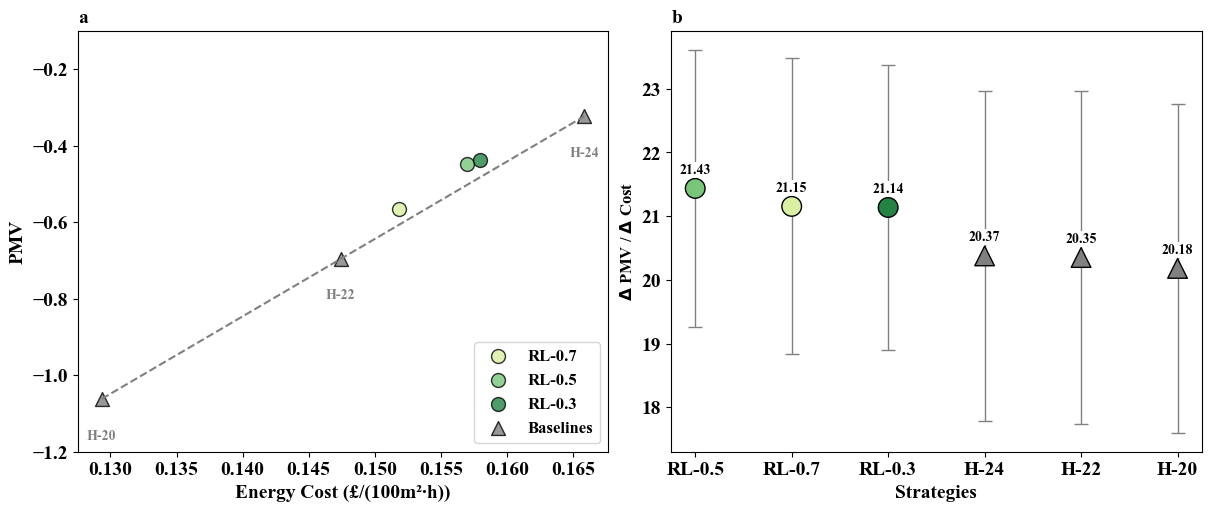

In [13]:
x = group_mean['weight'].unique()
y_reward = []
y_power = []
y_temp = []
y_reward_std = []
y_power_std = []
y_temp_std = []

ref_off_df = group_mean[(group_mean['model']=='ref_on_wasteheat_18') & (group_mean['weight']==0.5)] 
ref_off = {
    'reward': ref_off_df['reward'].values[0],
    'power_comp': ref_off_df['power_comp'].values[0],
    'temp_comp': ref_off_df['temp_comp'].values[0],
    'pmv': ref_off_df['pmv'].values[0],
}

for weight in x:
    dqn_row = group_mean[(group_mean['model']=='dqn') & (group_mean['weight']==weight)]
    y_reward.append(dqn_row['reward'].values[0])
    y_power.append(dqn_row['power_comp'].values[0])
    y_temp.append(dqn_row['pmv'].values[0])
    
    dqn_row_std = group_std[(group_std['model']=='dqn') & (group_std['weight']==weight)]
    y_reward_std.append(dqn_row_std['reward'].values[0])
    y_power_std.append(dqn_row_std['power_comp'].values[0])
    y_temp_std.append(dqn_row_std['pmv'].values[0])


# 画出reference点
y_power_line_ref= []
y_temp_line_ref = [] 
for ref in ['ref_on_wasteheat_24','ref_on_wasteheat_22', 'ref_on_wasteheat_20']:
    ref_row = group_mean[(group_mean['model']==ref)]
    y_power_line_ref.append(ref_row['power_comp'].values[0])
    y_temp_line_ref.append(ref_row['pmv'].values[0])

def plot_comparison(ax, y_power, y_temp, y_power_line_ref, y_temp_line_ref, ref_off, x):
    # 拟合曲线
    y_power_line = y_power
    y_temp_line = y_temp 
    z = np.polyfit(y_power_line, y_temp_line, 1)
    p = np.poly1d(z)
    x_fit = np.linspace(min(y_power_line), max(y_power_line), 100)
    y_fit = p(x_fit)
    print(f'Fitting line: y = {z[0]:.4f}x + {z[1]:.4f}')

    z_ref = np.polyfit(y_power_line_ref, y_temp_line_ref, 1)
    p_ref = np.poly1d(z_ref)
    x_fit_ref = np.linspace(min(y_power_line_ref), max(y_power_line_ref), 100)
    y_fit_ref = p_ref(x_fit_ref)
    ax.plot(x_fit_ref, y_fit_ref, "b--", label="", color='gray')
    # 打印拟合参数参考
    print(f'Fitting line Ref: y = {z_ref[0]:.4f}x + {z_ref[1]:.4f}')

    rate = [
        (t - ref_off['pmv']) / (p - ref_off['power_comp']) for t, p in zip(y_temp, y_power)
    ]
    rate_ref = [
        (t - ref_off['pmv']) / (p - ref_off['power_comp']) for t, p in zip(y_temp_line_ref, y_power_line_ref)
    ]
    print("Rate for DQN points:", rate)
    print("Rate for Reference points:", rate_ref)
    colors = sns.color_palette("YlGn", n_colors=len(y_power))
    for i in range(len(y_power)):
        ax.scatter(y_power[i], y_temp[i],
                s=100,
                color=colors[i], edgecolors='k', alpha=0.8,
                label=f'RL-{x[i]}')
    ax.scatter(y_power_line_ref, y_temp_line_ref, #s=[(r)*100 for r in rate_ref],
            #c = [24, 22, 20], 
            color = 'grey',
            marker='^',
            s=100,
            #cmap='Reds', 
            alpha=0.8,
            label='Baselines', edgecolors='k')
    lables = ['H-24','H-22','H-20']
    for i, r in enumerate(rate_ref):
        ax.annotate(f'{lables[i]}', (y_power_line_ref[i], y_temp_line_ref[i]-0.05), 
                    textcoords="offset points", xytext=(0,-15), ha='center', color='grey',
                    fontsize=10
                    )
    ax.grid(False)
    ax.legend(loc='lower right', frameon=True, fontsize=12)

    ax.set_ylabel('PMV')
    ax.set_xlabel('Energy Cost (£/(100m²·h))')
    ax.set_ylim(-1.2, -0.1)

def plot_comparison_ref(ax, group_mean_month):
    #rate = [
    #    (t - ref_off['pmv']) / (p - ref_off['power_comp']) for t, p in zip(y_temp, y_power)
    #]
    #rate_ref = [
    #    (t - ref_off['pmv']) / (p - ref_off['power_comp']) for t, p in zip(y_temp_line_ref, y_power_line_ref)
    #]
    #delta_pmv = [t - ref_off['pmv'] for t in y_temp_line_ref]
    #delta_cost = [p - ref_off['power_comp'] for p in y_power_line_ref]
    #delta_pmv_dqn = [t - ref_off['pmv'] for t in y_temp]
    #delta_cost_dqn = [p - ref_off['power_comp'] for p in y_power]
    #print("Delta PMV for Reference points:", delta_pmv)
    #print("Delta Cost for Reference points:", delta_cost)
    #print("Delta PMV for DQN points:", delta_pmv_dqn)
    #print("Delta Cost for DQN points:", delta_cost_dqn)
#
    ## 合并rate
    #names = ['H-24', 'H-22', 'H-20'] + [f'RL-{w}' for w in x]
    #values = rate_ref + rate
    ## 排序 根据rate值从大到小排序
    #sorted_indices = np.argsort(values)[::-1]
    #sorted_names = [names[i] for i in sorted_indices]
    #sorted_values = [values[i] for i in sorted_indices]
    #colors = ['grey']*len(x) + sns.color_palette("YlGn", n_colors=3)
    #colors = [colors[i] for i in sorted_indices]
    ## 排序
    #ax.bar(sorted_names, sorted_values, color=colors, edgecolor='k')
    # 按照model排序
    group_mean_month = group_mean_month.sort_values(by='efficiency', ascending=False)
    mean = group_mean_month.groupby('model')['efficiency'].mean().reset_index()['efficiency'].values
    std = group_mean_month.groupby('model')['efficiency'].std().reset_index()['efficiency'].values
    names = group_mean_month.groupby('model')['model'].first().values
    sorted_indices = np.argsort(mean)[::-1]
    sorted_names = [names[i] for i in sorted_indices]
    sorted_mean = [mean[i] for i in sorted_indices]
    sorted_std = [std[i] for i in sorted_indices]
    #sns.scatterplot(x='model', y='efficiency', data=group_mean_month, ax=ax, palette='YlGn', edgecolor='k')
    colors_raw = sns.color_palette("YlGn", n_colors=3) + ['grey']*3
    colors = colors_raw.copy()
    colors[0] = colors_raw[1]
    colors[1] = colors_raw[0]
    ax.errorbar(x=sorted_names, y=sorted_mean, yerr=sorted_std,
                fmt='o', color='none',
                ecolor='gray', 
                elinewidth=1, capsize=5, zorder=0)
    ax.scatter(sorted_names[0:3], sorted_mean[0:3], s=200, 
               color=colors[0:3], edgecolors='k', zorder=1)
    ax.scatter(sorted_names[3:6], sorted_mean[3:6], s=200, 
               marker='^',
               color=colors[3:6], edgecolors='k', zorder=1)
    
    # 在柱子上显示数值
    for i, v in enumerate(sorted_mean):
        ax.text(i, v + 0.19, f"{v:.2f}", ha='center', va='bottom', fontsize=10, 
                bbox=dict(facecolor='white', edgecolor='none', pad=1))
    sorted_names_dict = {
        'ref_on_wasteheat_24_0.5': 'H-24',
        'ref_on_wasteheat_22_0.5': 'H-22',
        'ref_on_wasteheat_20_0.5': 'H-20',
        'dqn_0.3': 'RL-0.3',
        'dqn_0.5': 'RL-0.5',
        'dqn_0.7': 'RL-0.7'
    }
    sorted_names = [sorted_names_dict[name] for name in sorted_names]
    ax.set_xticklabels(sorted_names)
    ax.set_ylabel('$\Delta$ PMV / $\Delta$ Cost', fontsize=12)
    ax.set_xlabel('Strategies')
    #ax.set_ylim(3.5, None)
    
def plot_pmv_target(ax):
    df_reward = pd.read_csv('reward_comparison.csv')
    df_reward['time'] = pd.to_datetime(df_reward['time'])
    df_reward['month'] = df_reward['time'].dt.month
    group_mean = df_reward.groupby(['model', 'weight', 'month']).mean().reset_index().sort_values(by='weight', ascending=False)
    
    group_mean_ref = group_mean[group_mean['model'].str.contains('ref_on_wasteheat_18')]
    
    group_mean = group_mean.loc[~group_mean['model'].str.contains('ref_on_wasteheat_18')]
    
    group_mean_merged = pd.merge(group_mean, group_mean_ref[['month', 'pmv']], on='month', suffixes=('', '_ref'))
    group_mean_merged['ratio'] = (group_mean_merged['pmv'] - group_mean_merged['pmv_ref']) / (group_mean_merged['power_comp'] - ref_off['power_comp'])
    group_mean_merged['type'] = group_mean_merged['model'] + '_' + group_mean_merged['weight'].astype(str)
    display(group_mean_merged)

        
        
fig, axs = plt.subplots(1, 2,
                        figsize=(12, 5), 
                        layout="constrained")
plot_comparison(axs[0], y_power, y_temp, y_power_line_ref, y_temp_line_ref, ref_off, x)
plot_comparison_ref(axs[1], group_mean_month)
plot_pmv_target(axs[1])
titles = ['a', 'b']
for ax, title in zip(axs, titles):
    ax.set_title(title, fontsize=14, fontweight='bold', loc='left')
#axs[1].set_ylim(18, None)
fig.savefig('figs/reward_comp_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
x = group_mean['weight'].unique()
y_reward = []
y_power = []
y_temp = []
y_reward_std = []
y_power_std = []
y_temp_std = []

ref_off_df = group_mean[(group_mean['model']=='ref_on_wasteheat_18') & (group_mean['weight']==0.5)] 
ref_off = {
    'reward': ref_off_df['reward'].values[0],
    'power_comp': ref_off_df['power_comp'].values[0],
    'temp_comp': ref_off_df['temp_comp'].values[0],
    'pmv': ref_off_df['pmv'].values[0],
}

for weight in x:
    dqn_row = group_mean[(group_mean['model']=='dqn') & (group_mean['weight']==weight)]
    y_reward.append(dqn_row['reward'].values[0])
    y_power.append(dqn_row['power_comp'].values[0])
    y_temp.append(dqn_row['pmv'].values[0])
    
    dqn_row_std = group_std[(group_std['model']=='dqn') & (group_std['weight']==weight)]
    y_reward_std.append(dqn_row_std['reward'].values[0])
    y_power_std.append(dqn_row_std['power_comp'].values[0])
    y_temp_std.append(dqn_row_std['pmv'].values[0])


# 画出reference点
y_power_line_ref= []
y_temp_line_ref = [] 
for ref in ['ref_on_wasteheat_24','ref_on_wasteheat_22', 'ref_on_wasteheat_20']:
    ref_row = group_mean[(group_mean['model']==ref)]
    y_power_line_ref.append(ref_row['power_comp'].values[0])
    y_temp_line_ref.append(ref_row['pmv'].values[0])

def plot_comparison(ax, y_power, y_temp, y_power_line_ref, y_temp_line_ref, ref_off, x):
    # 拟合曲线
    y_power_line = y_power
    y_temp_line = y_temp 
    z = np.polyfit(y_power_line, y_temp_line, 1)
    p = np.poly1d(z)
    x_fit = np.linspace(min(y_power_line), max(y_power_line), 100)
    y_fit = p(x_fit)
    print(f'Fitting line: y = {z[0]:.4f}x + {z[1]:.4f}')

    z_ref = np.polyfit(y_power_line_ref, y_temp_line_ref, 1)
    p_ref = np.poly1d(z_ref)
    x_fit_ref = np.linspace(min(y_power_line_ref), max(y_power_line_ref), 100)
    y_fit_ref = p_ref(x_fit_ref)
    ax.plot(x_fit_ref, y_fit_ref, "b--", label="", color='gray')
    # 打印拟合参数参考
    print(f'Fitting line Ref: y = {z_ref[0]:.4f}x + {z_ref[1]:.4f}')

    rate = [
        (t - ref_off['pmv']) / (p - ref_off['power_comp']) for t, p in zip(y_temp, y_power)
    ]
    rate_ref = [
        (t - ref_off['pmv']) / (p - ref_off['power_comp']) for t, p in zip(y_temp_line_ref, y_power_line_ref)
    ]
    print("Rate for DQN points:", rate)
    print("Rate for Reference points:", rate_ref)
    colors = sns.color_palette("YlGn", n_colors=len(y_power))
    for i in range(len(y_power)):
        ax.scatter(y_power[i], y_temp[i],
                s=100,
                color=colors[i], edgecolors='k', alpha=0.8,
                label=f'RL-{x[i]}')
    ax.scatter(y_power_line_ref, y_temp_line_ref, #s=[(r)*100 for r in rate_ref],
            #c = [24, 22, 20], 
            color = 'grey',
            marker='^',
            s=100,
            #cmap='Reds', 
            alpha=0.8,
            label='Baselines', edgecolors='k')
    lables = ['H-24','H-22','H-20']
    for i, r in enumerate(rate_ref):
        ax.annotate(f'{lables[i]}', (y_power_line_ref[i], y_temp_line_ref[i]-0.05), 
                    textcoords="offset points", xytext=(0,-15), ha='center', color='grey',
                    fontsize=10
                    )
    ax.grid(False)
    ax.legend(loc='lower right', frameon=True, fontsize=12)

    ax.set_ylabel('PMV')
    ax.set_xlabel('Energy Cost (£/(100m²·h))')
    ax.set_ylim(-1.2, -0.1)

def plot_comparison_ref(ax, y_power_line_ref, y_temp_line_ref):
    rate = [
        (t - ref_off['pmv']) / (p - ref_off['power_comp']) for t, p in zip(y_temp, y_power)
    ]
    rate_ref = [
        (t - ref_off['pmv']) / (p - ref_off['power_comp']) for t, p in zip(y_temp_line_ref, y_power_line_ref)
    ]
    delta_pmv = [t - ref_off['pmv'] for t in y_temp_line_ref]
    delta_cost = [p - ref_off['power_comp'] for p in y_power_line_ref]
    delta_pmv_dqn = [t - ref_off['pmv'] for t in y_temp]
    delta_cost_dqn = [p - ref_off['power_comp'] for p in y_power]
    print("Delta PMV for Reference points:", delta_pmv)
    print("Delta Cost for Reference points:", delta_cost)
    print("Delta PMV for DQN points:", delta_pmv_dqn)
    print("Delta Cost for DQN points:", delta_cost_dqn)

    # 合并rate
    names = ['H-24', 'H-22', 'H-20'] + [f'RL-{w}' for w in x]
    values = rate_ref + rate
    # 排序 根据rate值从大到小排序
    sorted_indices = np.argsort(values)[::-1]
    sorted_names = [names[i] for i in sorted_indices]
    sorted_values = [values[i] for i in sorted_indices]
    colors = ['grey']*len(x) + sns.color_palette("YlGn", n_colors=3)
    colors = [colors[i] for i in sorted_indices]
    # 排序
    ax.bar(sorted_names, sorted_values, color=colors, edgecolor='k')
    # 在柱子上显示数值
    for i, v in enumerate(sorted_values):
        ax.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylabel('$\Delta$ PMV / $\Delta$ Cost', fontsize=12)
    ax.set_xlabel('Strategies')
    ax.set_ylim(3.5, None)
    
def plot_pmv_target(ax):
    df_reward = pd.read_csv('reward_comparison.csv')
    df_reward['time'] = pd.to_datetime(df_reward['time'])
    df_reward['month'] = df_reward['time'].dt.month
    group_mean = df_reward.groupby(['model', 'weight', 'month']).mean().reset_index().sort_values(by='weight', ascending=False)
    
    group_mean_ref = group_mean[group_mean['model'].str.contains('ref_on_wasteheat_18')]
    
    group_mean = group_mean.loc[~group_mean['model'].str.contains('ref_on_wasteheat_18')]
    
    group_mean_merged = pd.merge(group_mean, group_mean_ref[['month', 'pmv']], on='month', suffixes=('', '_ref'))
    group_mean_merged['ratio'] = (group_mean_merged['pmv'] - group_mean_merged['pmv_ref']) / (group_mean_merged['power_comp'] - ref_off['power_comp'])
    group_mean_merged['type'] = group_mean_merged['model'] + '_' + group_mean_merged['weight'].astype(str)
    display(group_mean_merged)

        
        
fig, axs = plt.subplots(1, 2,
                        figsize=(12, 5), 
                        layout="constrained")
plot_comparison(axs[0], y_power, y_temp, y_power_line_ref, y_temp_line_ref, ref_off, x)
plot_comparison_ref(axs[1], y_power_line_ref, y_temp_line_ref)
plot_pmv_target(axs[1])
titles = ['a', 'b']
for ax, title in zip(axs, titles):
    ax.set_title(title, fontsize=14, fontweight='bold', loc='left')
axs[1].set_ylim(18, None)
fig.savefig('figs/reward_comp_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

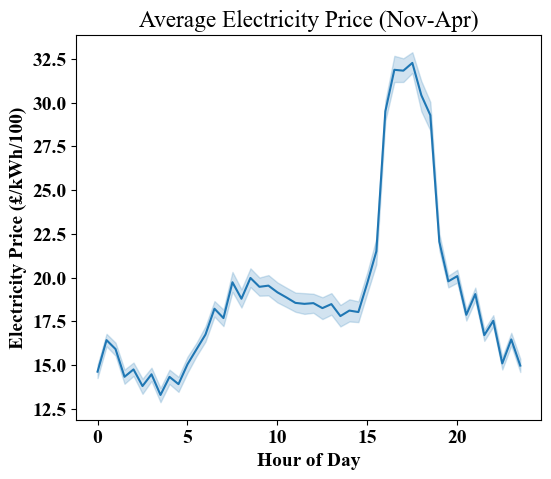

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

price_ele_ref = price_ele[(price_ele['month'] >= 11) | (price_ele['month'] <= 4)]

# groupby hour 
sns.lineplot(data=price_ele_ref, x='hour', y='ele_price', ax=ax)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Electricity Price (£/kWh/100)')
ax.set_title('Average Electricity Price (Nov-Apr)')
fig.savefig('figs/ele_price_by_hour.pdf', dpi=300, bbox_inches='tight')
plt.show()